# Two-Class Appointment Simulation Results (FCFS)

This notebook runs the appointment simulation under a single scheduling strategy: FCFS. It plots baseline access, delay, utilization, and total-arrival-rate sweep results.

The arrival parameterization used here is:

- `\lambda` = total expected arrival rate per slot
- `p` = share of class-1 arrivals
- `\lambda_1 = p\lambda`, `\lambda_2 = (1-p)\lambda`

Notation used here:

- `Y_t(r,m)` is the true slot-level calendar state.
- `X_{i,r}^D` is the derived day-start state summary.
- `r` is residual delay in the state.
- `\tau` is the original offered delay seen when the patient booked.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "appointment_simulation").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for module_name in list(sys.modules):
    if module_name == "appointment_simulation" or module_name.startswith("appointment_simulation."):
        del sys.modules[module_name]

from IPython.display import display

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from appointment_simulation import (
    FCFSPolicy,
    PatientClassConfig,
    SimulationConfig,
    green_savin_no_show,
    simulate,
    simulate_replications,
    split_two_class_arrival_rates,
    step_balking,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## Config presets

The active preset sets the simulation configuration, the total arrival rate `\lambda`, the class-1 demand share `p`, and the FCFS scheduling rule.


In [2]:
BASE_CLASS_SHARE = 7 / 12

CONFIG_PRESETS = {
    "baseline": {
        "simulation": dict(
            horizon_days=15,
            slots_per_day=25,
            burn_in_days=250,
            measure_days=1000,
            access_target_days=30,
            rng_seed=7,
        ),
        "classes": dict(total_lambda=0.24, class_1_share=BASE_CLASS_SHARE, balk_variant="baseline"),
        "policy": FCFSPolicy(),
        "notes": "Baseline FCFS run with step balking and source-aligned no-show curves.",
    },
    "low_load": {
        "simulation": dict(
            horizon_days=15,
            slots_per_day=25,
            burn_in_days=200,
            measure_days=800,
            access_target_days=30,
            rng_seed=11,
        ),
        "classes": dict(total_lambda=0.14, class_1_share=BASE_CLASS_SHARE, balk_variant="baseline"),
        "policy": FCFSPolicy(),
        "notes": "Lower congestion for near-immediate access and high service rates.",
    },
    "high_load": {
        "simulation": dict(
            horizon_days=15,
            slots_per_day=25,
            burn_in_days=300,
            measure_days=1000,
            access_target_days=30,
            rng_seed=17,
        ),
        "classes": dict(total_lambda=0.38, class_1_share=BASE_CLASS_SHARE, balk_variant="baseline"),
        "policy": FCFSPolicy(),
        "notes": "Heavier load to study congestion and lower realized service.",
    },
    "strict_balking": {
        "simulation": dict(
            horizon_days=15,
            slots_per_day=25,
            burn_in_days=250,
            measure_days=1000,
            access_target_days=30,
            rng_seed=23,
        ),
        "classes": dict(total_lambda=0.24, class_1_share=BASE_CLASS_SHARE, balk_variant="strict"),
        "policy": FCFSPolicy(),
        "notes": "Same total demand as baseline but with earlier balk thresholds and higher balk levels.",
    },
}

ACTIVE_PRESET = "baseline"

pd.DataFrame(
    [
        {
            "preset": name,
            "lambda_total": preset["classes"]["total_lambda"],
            "class_1_share_p": preset["classes"]["class_1_share"],
            "balk_variant": preset["classes"]["balk_variant"],
            "policy": type(preset["policy"]).__name__,
            "horizon_days": preset["simulation"]["horizon_days"],
            "slots_per_day": preset["simulation"]["slots_per_day"],
            "measure_days": preset["simulation"]["measure_days"],
            "access_target_days": preset["simulation"]["access_target_days"],
            "seed": preset["simulation"]["rng_seed"],
            "notes": preset["notes"],
        }
        for name, preset in CONFIG_PRESETS.items()
    ]
).set_index("preset")


,lambda_total,class_1_share_p,balk_variant,policy,horizon_days,slots_per_day,measure_days,access_target_days,seed,notes
preset,,,,,,,,,,
baseline,0.24,0.583333,baseline,FCFSPolicy,15,25,1000,30,7,Baseline FCFS run with step balking and source...
low_load,0.14,0.583333,baseline,FCFSPolicy,15,25,800,30,11,Lower congestion for near-immediate access and...
high_load,0.38,0.583333,baseline,FCFSPolicy,15,25,1000,30,17,Heavier load to study congestion and lower rea...
strict_balking,0.24,0.583333,strict,FCFSPolicy,15,25,1000,30,23,Same total demand as baseline but with earlier...


In [3]:
def make_classes(total_lambda=0.24, class_1_share=7 / 12, balk_variant="baseline"):
    lambda_1, lambda_2 = split_two_class_arrival_rates(total_lambda, class_1_share)

    if balk_variant == "baseline":
        balk_1 = step_balking(threshold=4, low_delay_probability=0.05, high_delay_probability=0.60)
        balk_2 = step_balking(threshold=3, low_delay_probability=0.08, high_delay_probability=0.70)
    else:
        balk_1 = step_balking(threshold=2, low_delay_probability=0.10, high_delay_probability=0.85)
        balk_2 = step_balking(threshold=2, low_delay_probability=0.12, high_delay_probability=0.90)

    return [
        PatientClassConfig(
            class_id=1,
            label="class_1 (MRI-like)",
            arrival_rate=lambda_1,
            balk_probability=balk_1,
            cancel_probability=0.10,
            no_show_probability=green_savin_no_show(gamma_0=0.01, gamma_max=0.31, sensitivity=50.0),
        ),
        PatientClassConfig(
            class_id=2,
            label="class_2 (mental-health-like)",
            arrival_rate=lambda_2,
            balk_probability=balk_2,
            cancel_probability=0.06,
            no_show_probability=green_savin_no_show(gamma_0=0.15, gamma_max=0.51, sensitivity=9.0),
        ),
    ]


ACTIVE_CONFIG = CONFIG_PRESETS[ACTIVE_PRESET]
BASE_CONFIG = SimulationConfig(**ACTIVE_CONFIG["simulation"])
BASE_CLASSES = make_classes(**ACTIVE_CONFIG["classes"])
BASE_POLICY = ACTIVE_CONFIG["policy"]
BASE_CLASS_SHARE = ACTIVE_CONFIG["classes"]["class_1_share"]
BASE_BALK_VARIANT = ACTIVE_CONFIG["classes"]["balk_variant"]


def sweep_total_arrival_rate(total_lambdas, replications=5, policy=None, class_1_share=None, balk_variant=None):
    class_1_share = BASE_CLASS_SHARE if class_1_share is None else class_1_share
    balk_variant = BASE_BALK_VARIANT if balk_variant is None else balk_variant
    aggregate_rows = []
    class_rows = []

    for scenario_id, total_lambda in enumerate(total_lambdas):
        lambda_1, lambda_2 = split_two_class_arrival_rates(total_lambda, class_1_share)
        results = simulate_replications(
            make_classes(total_lambda=total_lambda, class_1_share=class_1_share, balk_variant=balk_variant),
            config=BASE_CONFIG,
            policy=policy,
            replications=replications,
            base_seed=100 + scenario_id * replications,
        )
        for replication, result in enumerate(results):
            aggregate_rows.append(
                {
                    "lambda_total": total_lambda,
                    "class_1_share": class_1_share,
                    "replication": replication,
                    "mean_delay_booked": result.summary_aggregate["mean_delay_booked"],
                    "booked_within_access_target_per_arrival": result.summary_aggregate[
                        "booked_within_access_target_per_arrival"
                    ],
                    "served_per_booked": result.summary_aggregate["served_per_booked"],
                    "booked_slot_utilization": result.slot_summary_aggregate["booked_slot_utilization"],
                    "attended_slot_utilization": result.slot_summary_aggregate["attended_slot_utilization"],
                }
            )

            class_frame = result.summary_by_class[
                ["class_id", "label", "mean_delay_booked", "booked_within_access_target_per_arrival", "served_per_booked"]
            ].copy()
            class_frame["lambda_total"] = total_lambda
            class_frame["class_1_share"] = class_1_share
            class_frame["replication"] = replication
            class_rows.append(class_frame)

    aggregate_df = pd.DataFrame(aggregate_rows)
    class_df = pd.concat(class_rows, ignore_index=True)
    return aggregate_df, class_df


## Baseline simulation

In [4]:
baseline_result = simulate(BASE_CLASSES, config=BASE_CONFIG, policy=BASE_POLICY)

baseline_result.summary_by_class

,class_id,label,arrivals,booked,balked,no_offer,not_booked,booked_within_access_target,canceled,no_shows,served,still_scheduled_end,mean_delay_booked,mean_delay_served,served_per_booked,booked_per_arrival,booked_within_access_target_per_arrival,booked_within_access_target_per_booked
0,1,class_1 (MRI-like),3456,3291,165,0,165,3291,11,48,3232,0,0.040413,0.036819,0.982072,0.952257,0.952257,1.0
1,2,class_2 (mental-health-like),2497,2295,202,0,202,2295,8,343,1944,0,0.041830,0.038066,0.847059,0.919103,0.919103,1.0


In [5]:
baseline_metrics = pd.Series(
    {
        "aggregate_mean_booked_delay": baseline_result.summary_aggregate["mean_delay_booked"],
        "booked_within_access_target_per_arrival": baseline_result.summary_aggregate[
            "booked_within_access_target_per_arrival"
        ],
        "booked_within_access_target_per_booked": baseline_result.summary_aggregate[
            "booked_within_access_target_per_booked"
        ],
        "aggregate_service_rate": baseline_result.summary_aggregate["served_per_booked"],
        "booked_slot_utilization": baseline_result.slot_summary_aggregate["booked_slot_utilization"],
        "attended_slot_utilization": baseline_result.slot_summary_aggregate["attended_slot_utilization"],
        "empty_slots": baseline_result.slot_summary_aggregate["empty_slots"],
    }
).rename("value")

baseline_state = (
    baseline_result.state_log
    .query("measured_day == 0")
    .pivot(index="class_id", columns="residual_delay", values="count")
    .fillna(0)
    .astype(int)
)
baseline_state.columns = [f"r={col}" for col in baseline_state.columns]

baseline_daily_journal = baseline_result.daily_journal_aggregate.head(10).rename(
    columns={"mean_tau_booked_new_bookings": "mean_tau_new_bookings"}
)

display(baseline_metrics)
display(baseline_state)
baseline_daily_journal

aggregate_mean_booked_delay                    0.040995
booked_within_access_target_per_arrival        0.938350
booked_within_access_target_per_booked         1.000000
aggregate_service_rate                         0.926602
booked_slot_utilization                        0.222680
attended_slot_utilization                      0.207040
empty_slots                                19433.000000
Name: value, dtype: float64

,r=0,r=1,r=2,r=3,r=4,r=5,r=6,r=7,r=8,r=9,r=10,r=11,r=12,r=13,r=14
class_id,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,day,measured_day,label,scheduled_start_of_day,scheduled_for_today_start,arrivals,booked,balked,no_offer,not_booked,booked_within_access_target,canceled,no_shows,served,booked_slots,served_slots,no_show_slots,empty_slots,mean_tau_new_bookings,booked_per_arrival,booked_within_access_target_per_arrival,booked_within_access_target_per_booked,served_per_booked,booked_slot_utilization,attended_slot_utilization
0,250,0,all,0,0,5,5,0,0,0,5,0,0,5,5,5,0,20,0.000000,1.000000,1.000000,1.0,1.000000,0.20,0.20
1,251,1,all,0,0,5,5,0,0,0,5,0,1,4,5,4,1,20,0.000000,1.000000,1.000000,1.0,0.800000,0.20,0.16
2,252,2,all,0,0,3,3,0,0,0,3,0,1,2,3,2,1,22,0.000000,1.000000,1.000000,1.0,0.666667,0.12,0.08
3,253,3,all,0,0,5,5,0,0,0,5,0,0,5,5,5,0,20,0.000000,1.000000,1.000000,1.0,1.000000,0.20,0.20
4,254,4,all,0,0,4,3,1,0,1,3,0,0,3,3,3,0,22,0.000000,0.750000,0.750000,1.0,1.000000,0.12,0.12
5,255,5,all,0,0,6,6,0,0,0,6,0,1,5,6,5,1,19,0.000000,1.000000,1.000000,1.0,0.833333,0.24,0.20
6,256,6,all,0,0,10,9,1,0,1,9,0,0,8,8,8,0,17,0.111111,0.900000,0.900000,1.0,0.888889,0.32,0.32
7,257,7,all,1,1,8,6,2,0,2,6,0,1,6,7,6,1,18,0.000000,0.750000,0.750000,1.0,1.000000,0.28,0.24
8,258,8,all,0,0,8,7,1,0,1,7,0,0,7,7,7,0,18,0.000000,0.875000,0.875000,1.0,1.000000,0.28,0.28
9,259,9,all,0,0,7,6,1,0,1,6,0,0,6,6,6,0,19,0.000000,0.857143,0.857143,1.0,1.000000,0.24,0.24


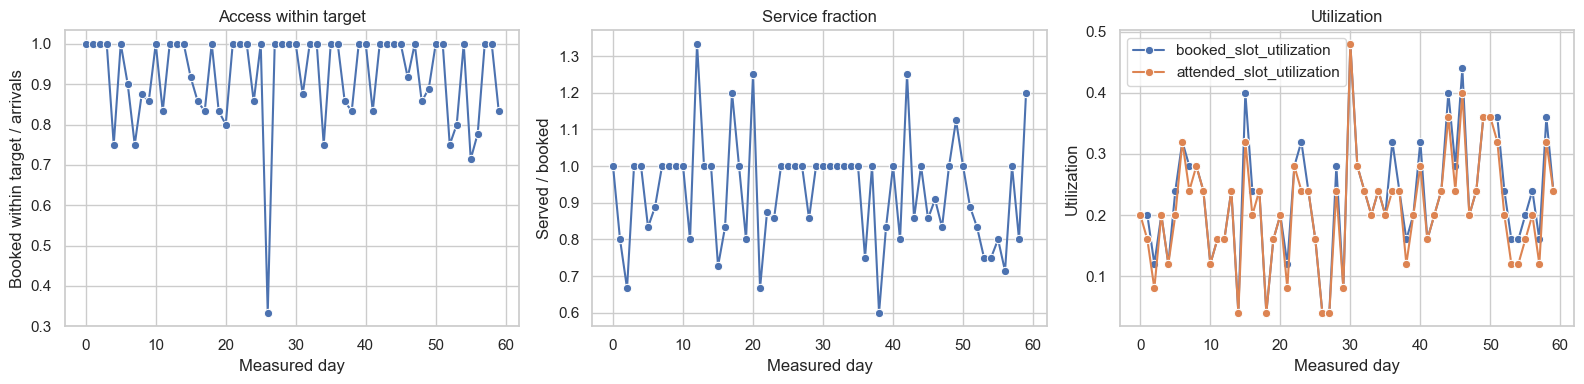

In [6]:
journal_window = baseline_result.daily_journal_aggregate.head(60).copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

sns.lineplot(
    data=journal_window,
    x="measured_day",
    y="booked_within_access_target_per_arrival",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Access within target")
axes[0].set_xlabel("Measured day")
axes[0].set_ylabel("Booked within target / arrivals")

sns.lineplot(data=journal_window, x="measured_day", y="served_per_booked", marker="o", ax=axes[1])
axes[1].set_title("Service fraction")
axes[1].set_xlabel("Measured day")
axes[1].set_ylabel("Served / booked")

util_df = journal_window[["measured_day", "booked_slot_utilization", "attended_slot_utilization"]].melt(
    id_vars="measured_day",
    var_name="metric",
    value_name="value",
)
sns.lineplot(data=util_df, x="measured_day", y="value", hue="metric", marker="o", ax=axes[2])
axes[2].set_title("Utilization")
axes[2].set_xlabel("Measured day")
axes[2].set_ylabel("Utilization")
axes[2].legend(title="")

plt.tight_layout()

## Total-arrival-rate sweep

The sweep below varies the total demand rate `\lambda` while holding the class mix `p` fixed.


In [7]:
total_lambdas = [0.14, 0.21, 0.28, 0.35, 0.42]
aggregate_df, class_df = sweep_total_arrival_rate(total_lambdas, replications=5, policy=FCFSPolicy())

display(aggregate_df.head())
class_df.head()


,lambda_total,class_1_share,replication,mean_delay_booked,booked_within_access_target_per_arrival,served_per_booked,booked_slot_utilization,attended_slot_utilization
0,0.14,0.583333,0,0.038887,0.942487,0.931499,0.13340,0.12456
1,0.14,0.583333,1,0.041704,0.934057,0.935955,0.13384,0.12568
2,0.14,0.583333,2,0.039883,0.932713,0.930499,0.13592,0.12692
3,0.14,0.583333,3,0.041200,0.935923,0.930021,0.13176,0.12284
4,0.14,0.583333,4,0.042832,0.934668,0.933076,0.13400,0.12548


,class_id,label,mean_delay_booked,booked_within_access_target_per_arrival,served_per_booked,lambda_total,class_1_share,replication
0,1,class_1 (MRI-like),0.039960,0.953690,0.989378,0.14,0.583333,0
1,2,class_2 (mental-health-like),0.037335,0.926730,0.847731,0.14,0.583333,0
2,1,class_1 (MRI-like),0.046859,0.948912,0.984546,0.14,0.583333,1
3,2,class_2 (mental-health-like),0.034049,0.912838,0.863805,0.14,0.583333,1
4,1,class_1 (MRI-like),0.040494,0.945820,0.986173,0.14,0.583333,2


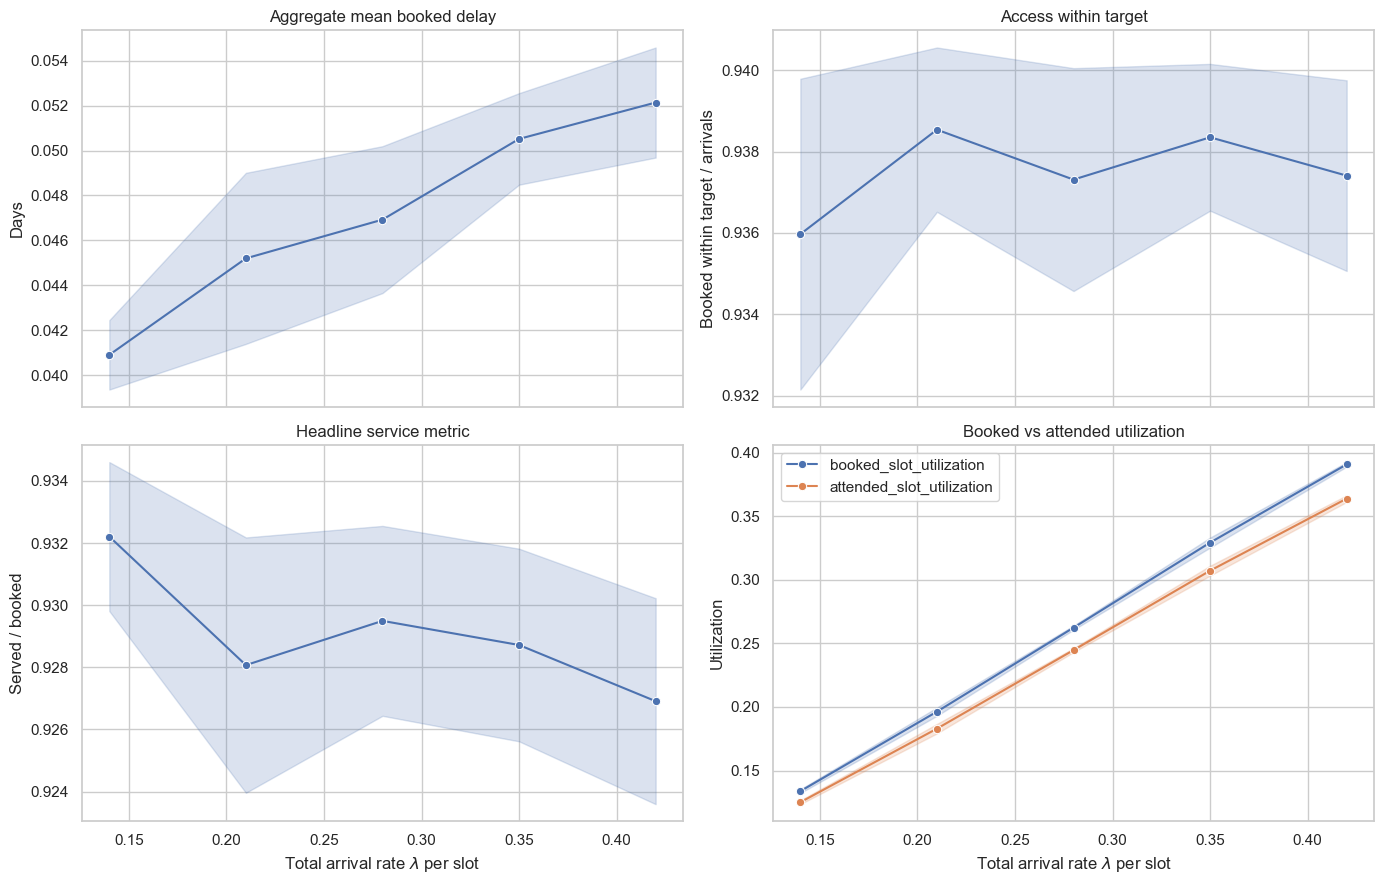

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

sns.lineplot(
    data=aggregate_df,
    x="lambda_total",
    y="mean_delay_booked",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Aggregate mean booked delay")
axes[0, 0].set_xlabel(r"Total arrival rate $\lambda$ per slot")
axes[0, 0].set_ylabel("Days")

sns.lineplot(
    data=aggregate_df,
    x="lambda_total",
    y="booked_within_access_target_per_arrival",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Access within target")
axes[0, 1].set_xlabel(r"Total arrival rate $\lambda$ per slot")
axes[0, 1].set_ylabel("Booked within target / arrivals")

sns.lineplot(
    data=aggregate_df,
    x="lambda_total",
    y="served_per_booked",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Headline service metric")
axes[1, 0].set_xlabel(r"Total arrival rate $\lambda$ per slot")
axes[1, 0].set_ylabel("Served / booked")

util_sweep_df = aggregate_df[["lambda_total", "booked_slot_utilization", "attended_slot_utilization"]].melt(
    id_vars="lambda_total",
    var_name="metric",
    value_name="value",
)
sns.lineplot(
    data=util_sweep_df,
    x="lambda_total",
    y="value",
    hue="metric",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Booked vs attended utilization")
axes[1, 1].set_xlabel(r"Total arrival rate $\lambda$ per slot")
axes[1, 1].set_ylabel("Utilization")
axes[1, 1].legend(title="")

plt.tight_layout()


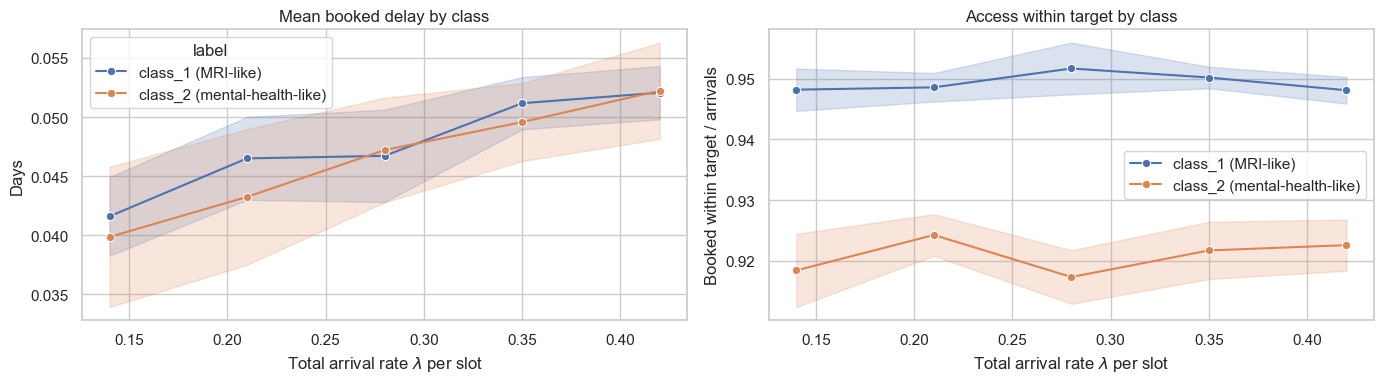

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

sns.lineplot(
    data=class_df,
    x="lambda_total",
    y="mean_delay_booked",
    hue="label",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Mean booked delay by class")
axes[0].set_xlabel(r"Total arrival rate $\lambda$ per slot")
axes[0].set_ylabel("Days")

sns.lineplot(
    data=class_df,
    x="lambda_total",
    y="booked_within_access_target_per_arrival",
    hue="label",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Access within target by class")
axes[1].set_xlabel(r"Total arrival rate $\lambda$ per slot")
axes[1].set_ylabel("Booked within target / arrivals")
axes[1].legend(title="")

plt.tight_layout()
